In [ ]:
import marimo as mo

# [Circular Dependency Check](https://www.thequerylab.com/problems/211-circular-dependency-check)

Write a query to identify all employees who are part of such a circular chain. An employee is considered part of a circular dependency if they appear anywhere within a reporting loop.

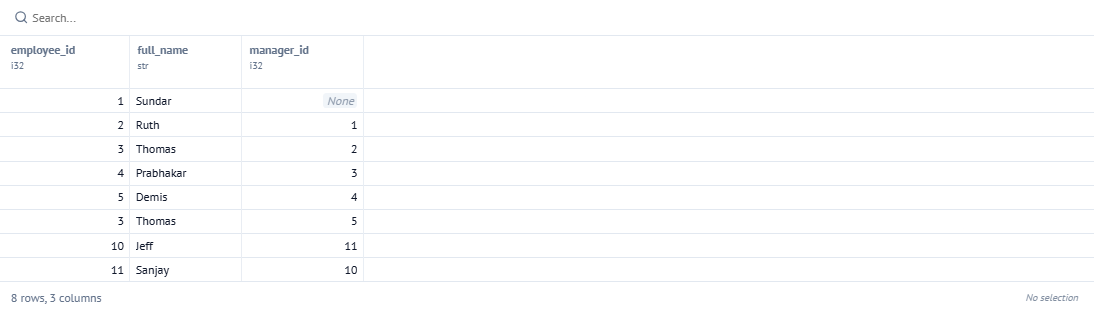

In [ ]:
_df = mo.sql(
    f"""
    DROP TABLE IF EXISTS employees_hierarchy;

    CREATE TABLE employees_hierarchy (
    	employee_id INT,
    	full_name VARCHAR,
    	manager_id INT
    );

    INSERT INTO employees_hierarchy
    VALUES
    	(1, 'Sundar', NULL),
    	(2, 'Ruth', 1),
    	(3, 'Thomas', 2),
    	(4, 'Prabhakar', 3),
    	(5, 'Demis', 4),
    	(3, 'Thomas', 5),
    	(10, 'Jeff', 11),
    	(11, 'Sanjay', 10);

    SELECT
    	*
    FROM
    	employees_hierarchy;
    """
)

# Solution

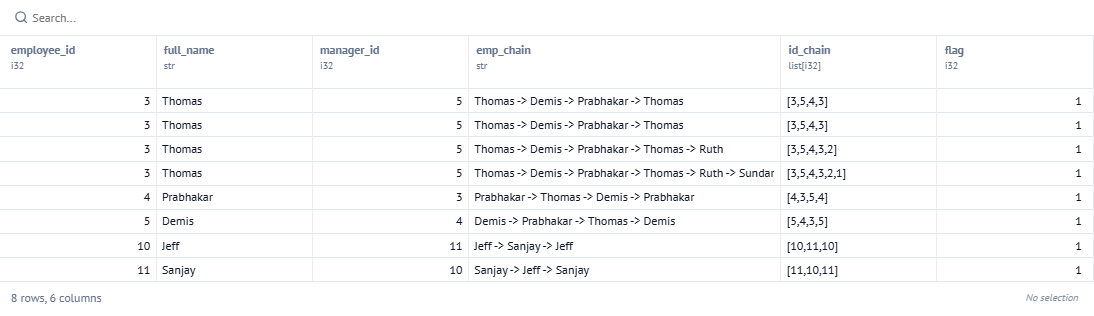

In [ ]:
_df = mo.sql(
    f"""
    WITH RECURSIVE
    	employees_hierarchy_recursive AS (
    		-- anchor part
    		SELECT
    			employee_id,
    			full_name,
    			manager_id,
    			full_name AS emp_chain,
    			ARRAY[employee_id] AS id_chain,
    			0 AS flag
    		FROM
    			employees_hierarchy
    		UNION ALL
    		-- recursive part
    		SELECT
    			eh.employee_id,
    			eh.full_name,
    			eh.manager_id,
    			(eh.full_name || ' -> ' || ehr.emp_chain) AS emp_chain,
    			ARRAY[eh.employee_id] || ehr.id_chain AS id_chain,
    			CASE
    				WHEN eh.employee_id = ANY (ehr.id_chain) THEN 1
    				ELSE 0
    			END AS flag
    		FROM
    			employees_hierarchy AS eh
    			INNER JOIN employees_hierarchy_recursive AS ehr ON eh.manager_id = ehr.employee_id
    		WHERE
    			ehr.flag = 0
    	)
    SELECT
    	*
    FROM
    	employees_hierarchy_recursive
    WHERE
    	flag = 1
    ORDER BY
    	1 ASC;
    """
)